# The Office: Predicting Episode Quality from Dialogue Features
**DATA200 Final Project**

**Group Members:** Eashin, Rachel Ishola, Ashraf

---

## 1. Introduction

### Problem in Context

*The Office* (US) aired from 2005 to 2013 across nine seasons, and is widely regarded as one of the greatest sitcoms in television history. The show underwent a dramatic shift in Season 7 when its lead character, Michael Scott (Steve Carell), departed, an event widely discussed as a turning point in the show's quality.

This project investigates whether **dialogue patterns and episode characteristics can predict episode quality**, as measured by IMDb ratings. We combine three datasets: episode-level metadata (viewership, director, writer), IMDb ratings, and full dialogue transcripts to engineer meaningful features and build predictive models.

### Research Goals

1. **Regression:** Predict the IMDb rating of an episode from dialogue and episode features.
2. **Classification:** Classify whether an episode is a *super hit* (IMDb ≥ 8.5) or not.
3. **Clustering:** Discover natural groupings of episodes based on dialogue patterns, and examine whether they align with the Michael/post-Michael era.

### Data Description

We use three datasets:

| Dataset | Rows | Key Variables |
|---|---|---|
| `The-Office-Lines-V4.csv` | 54,626 | `season`, `episode`, `speaker`, `line`, `scene` |
| `the_office_episodes.csv` | 201 | `season`, `episode_num_in_season`, `us_viewers`, `directed_by`, `written_by` |
| `TheOfficeIMDBPerEpisode.csv` | 188 | `Season`, `Title`, `Rating`, `Num_Votes` |

After joining and aggregating to the episode level, our final dataset contains **186 episodes**.

---
## 2. Data Loading & Cleaning

In [ ]:
!pip install vaderSentiment -q

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

In [ ]:
# Load raw data
lines_raw   = pd.read_csv('The-Office-Lines-V4.csv')
episodes    = pd.read_csv('the_office_episodes.csv')
imdb        = pd.read_csv('TheOfficeIMDBPerEpisode.csv')

print(f'Lines: {lines_raw.shape}, Episodes: {episodes.shape}, IMDB: {imdb.shape}')

Lines: (54626, 7), Episodes: (201, 9), IMDB: (188, 8)


### 2.1 Cleaning the Lines Dataset

The lines dataset contains stage directions embedded in square brackets (e.g. `[laughing]`). We use regex to strip these, then remove any lines that become empty after cleaning.

In [ ]:
# Drop junk column
lines = lines_raw.drop(columns=['Unnamed: 6'])

# Regex: strip stage directions in [brackets]
lines['line_clean'] = lines['line'].apply(
    lambda x: re.sub(r'\[.*?\]', '', str(x)).strip()
)

# Remove lines that are now empty
n_before = len(lines)
lines = lines[lines['line_clean'] != '']
print(f'Removed {n_before - len(lines)} empty lines after cleaning stage directions.')
lines.head(3)

Removed 6 empty lines after cleaning stage directions.


,season,episode,title,scene,speaker,line,line_clean
0,1,1,Pilot,1,Michael,All right Jim. Your quarterlies look very good...,All right Jim. Your quarterlies look very good...
1,1,1,Pilot,1,Jim,"Oh, I told you. I couldn't close it. So...","Oh, I told you. I couldn't close it. So..."
2,1,1,Pilot,1,Michael,So you've come to the master for guidance? Is ...,So you've come to the master for guidance? Is ...


### 2.2 Cleaning the Episodes Dataset

The `written_by` column often contains multiple writers separated by `&` or `|`. We use regex to extract the **primary writer** (first listed) as a clean categorical feature.

In [ ]:
# Extract primary writer using regex
episodes['primary_writer'] = episodes['written_by'].apply(
    lambda x: re.split(r'[&|,]', str(x))[0].strip()
)

# Parse air date
episodes['air_date'] = pd.to_datetime(episodes['original_air_date'])
episodes['year'] = episodes['air_date'].dt.year

# Standardise column name for joining
episodes = episodes.rename(columns={'episode_num_in_season': 'episode'})

print(f'Top 5 primary writers:')
print(episodes['primary_writer'].value_counts().head())

Top 5 primary writers:
primary_writer
Mindy Kaling        21
Paul Lieberstein    18
B. J. Novak         15
Jennifer Celotta    14
Greg Daniels        13
Name: count, dtype: int64


---
## 3. Exploratory Data Analysis

### 3.1 IMDb Rating Distribution

Before modelling, we examine the distribution of our target variable as a guide.

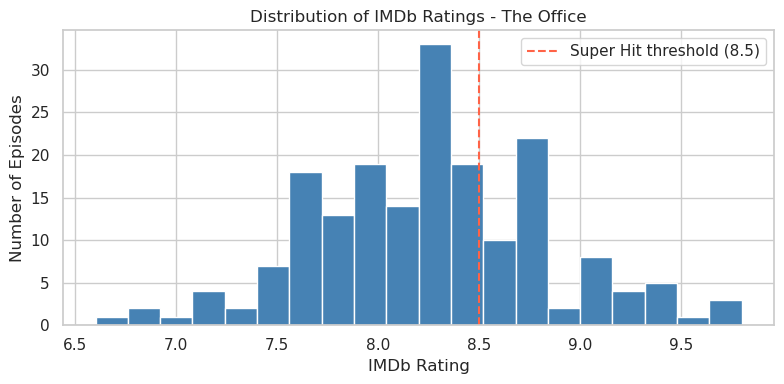

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(imdb['Rating'], bins=20, color='steelblue', edgecolor='white')
ax.axvline(8.5, color='tomato', linestyle='--', linewidth=1.5, label='Super Hit threshold (8.5)')
ax.set_xlabel('IMDb Rating')
ax.set_ylabel('Number of Episodes')
ax.set_title('Distribution of IMDb Ratings - The Office')
ax.legend()
plt.tight_layout()
plt.show()

The histogram shows the distribution of IMbb ratings through the episodes of The Office. All ratings fall between about 6.5 and 10. There is also theconcentration between about 7.5 and 9.0 indicating generally strong, consistent ratings for most of the show. Ratings are roughly normally distributed with a slight right skew, centred around 8.3. We define a **super hit episode** as one with a rating ≥ 8.5, giving us a reasonable class split for classification. According to our definition of a hit episode, several episodes exceed this threshold but are fewer compared to the overall total. Around the range of 8.3 is where we have a peak of the most number of episodes. 

### 3.2 Average Rating & Viewership by Season

We use split-apply-combine to compute per-season averages, and plot both metrics to examine whether the Michael Scott departure (Season 7, Ep "Goodbye, Michael") coincides with a measurable quality drop.

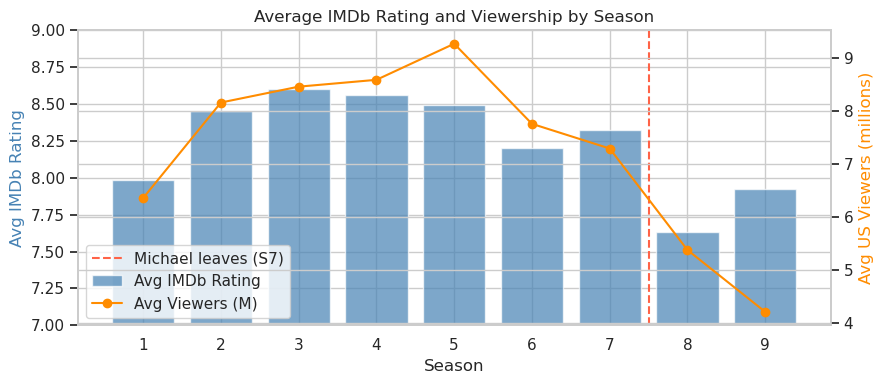

In [ ]:
# For EDA purposes, aggregate directly from imdb + episodes via title merge
season_agg = imdb.groupby('Season').agg(
    avg_rating=('Rating', 'mean'),
    num_episodes=('Rating', 'count')
).reset_index()

ep_season = episodes.groupby('season').agg(
    avg_viewers=('us_viewers', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 4))
color1 = 'steelblue'
ax1.bar(season_agg['Season'], season_agg['avg_rating'], color=color1, alpha=0.7, label='Avg IMDb Rating')
ax1.set_xlabel('Season')
ax1.set_ylabel('Avg IMDb Rating', color=color1)
ax1.set_ylim(7, 9)
ax1.axvline(7.5, color='tomato', linestyle='--', linewidth=1.5, label='Michael leaves (S7)')

ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.plot(ep_season['season'], ep_season['avg_viewers']/1e6, 'o-', color=color2, label='Avg Viewers (M)')
ax2.set_ylabel('Avg US Viewers (millions)', color=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
ax1.set_title('Average IMDb Rating and Viewership by Season')
ax1.set_xticks(range(1, 10))
plt.tight_layout()
plt.show()

This plot compares the average IMDb rating and average U.S. viewership for each season. The bar chart shows the rating decline from Season 7 to Season 8 but somewhat bounces back for the final lap of season 9. Ratings appeared fairly consisitent however the line graph shows that the viewership declined drastically in the later seasons. The viewership rises in the earlier seasons as with most shows and then peaks in season 5, gradual decline till Season 7 and then drastically after that. After Michael leaves the show at season 7, both ratings and viewership took on an undeniable downward trend suggesting a possible direct impact. 

### 3.3 Michael Scott's Share of Dialogue Over the Series

We examine how Michael's proportion of dialogue evolves, using split-apply-combine on the lines dataset.

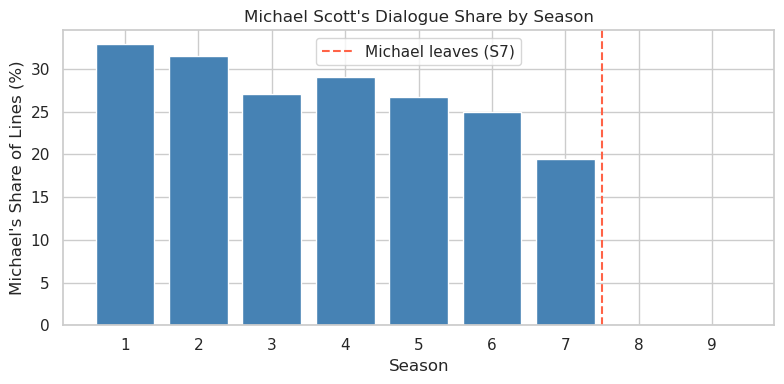

In [ ]:
# Split-apply-combine: Michael's dialogue share per season
michael_agg = lines.groupby('season').apply(
    lambda df: pd.Series({
        'michael_pct': (df['speaker'] == 'Michael').mean() * 100
    }),
    include_groups=False
).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(michael_agg['season'], michael_agg['michael_pct'], color='steelblue', edgecolor='white')
ax.axvline(7.5, color='tomato', linestyle='--', linewidth=1.5, label='Michael leaves (S7)')
ax.set_xlabel('Season')
ax.set_ylabel('Michael\'s Share of Lines (%)')
ax.set_title('Michael Scott\'s Dialogue Share by Season')
ax.set_xticks(range(1, 10))
ax.legend()
plt.tight_layout()
plt.show()

This bar chart shows Michael Scott's share of dialogue across seasons. In earlier seasons, his percentage of lines is quite high, covering about 33% which reflects his central role in the show. As seasons progress, his dialogue share remains fairly consistent, still covering at least a quarter (25%) or more of the show until Season 7 where his presence dwindles. The dashed vertical line is placed at Season 7 which makes his departure and his share drops to zero. Overall, this plot illustrates so clearly how integral Michael was to the show's dialogue. 

---
## 4. Feature Engineering

We aggregate the lines dataset to the episode level and engineer the following features:

| Feature | Type | Description |
|---|---|---|
| `total_lines` | Discrete | Total number of dialogue lines |
| `scene_count` | Discrete | Number of unique scenes |
| `michael_pct` | Continuous | Michael's share of all lines |
| `sentiment_score` | Continuous | Mean VADER compound sentiment |
| `vocab_richness` | Continuous | Unique words / total words |
| `us_viewers` | Continuous | US viewership count |
| `season` | Categorical | Season number (1–9) |
| `primary_writer` | Categorical | First listed writer |

In [ ]:
# Compute VADER sentiment per line
analyzer = SentimentIntensityAnalyzer()
lines['sentiment'] = lines['line_clean'].apply(
    lambda x: analyzer.polarity_scores(x)['compound']
)
lines['word_count'] = lines['line_clean'].apply(lambda x: len(x.split()))

# Aggregate to episode level
episode_features = lines.groupby(['season', 'episode']).agg(
    total_lines   = ('line', 'count'),
    scene_count   = ('scene', 'nunique'),
    michael_lines = ('speaker', lambda x: (x == 'Michael').sum()),
    sentiment_score = ('sentiment', 'mean'),
    total_words   = ('word_count', 'sum'),
    unique_words  = ('line_clean', lambda x: len(set(' '.join(x).lower().split())))
).reset_index()

episode_features['michael_pct']    = episode_features['michael_lines'] / episode_features['total_lines']
episode_features['vocab_richness'] = episode_features['unique_words']  / episode_features['total_words']

print(f'Episode features shape: {episode_features.shape}')
episode_features.head(3)

Episode features shape: (186, 10)


,season,episode,total_lines,scene_count,michael_lines,sentiment_score,total_words,unique_words,michael_pct,vocab_richness
0,1,1,228,39,81,0.149714,2756,982,0.355263,0.356313
1,1,2,203,29,75,0.213707,2812,960,0.369458,0.341394
2,1,3,243,38,55,0.080078,2723,945,0.226337,0.347044


### 4.1 Joining All Three Datasets

In [ ]:
# Join 1: episode features + episode metadata
df = episode_features.merge(episodes, on=['season', 'episode'])

# Join 2: + IMDb ratings (on season + title)
df = df.merge(
    imdb[['Season', 'Title', 'Rating', 'Num_Votes']],
    left_on=['season', 'title'],
    right_on=['Season', 'Title'],
    how='left'
).drop(columns=['Season', 'Title'])

# Drop rows without ratings (multi-part episodes missing from IMDB)
df = df.dropna(subset=['Rating'])

# Binary target for classification
df['high_rated'] = (df['Rating'] >= 8.5).astype(int)

# Michael era flag
df['michael_era'] = (df['season'] <= 7).astype(int)

print(f'Final dataset: {df.shape}')
print(f'Hit episodes (rating >= 8.5): {df["high_rated"].sum()} / {len(df)}')
df[['season','episode','title','michael_pct','sentiment_score','vocab_richness','us_viewers','Rating','high_rated']].head(6)

Final dataset: (186, 24)
Hit episodes (rating >= 8.5): 61 / 186


,season,episode,title,michael_pct,sentiment_score,vocab_richness,us_viewers,Rating,high_rated
0,1,1,Pilot,0.355263,0.149714,0.356313,11200000.0,7.5,0
1,1,2,Diversity Day,0.369458,0.213707,0.341394,6000000.0,8.3,0
2,1,3,Health Care,0.226337,0.080078,0.347044,5800000.0,7.8,0
3,1,4,The Alliance,0.279835,0.179163,0.365646,5400000.0,8.1,0
4,1,5,Basketball,0.452174,0.137730,0.370188,5000000.0,8.4,0
5,1,6,Hot Girl,0.311765,0.176667,0.341431,4800000.0,7.8,0


---
## 5. Modelling

### 5.1 Feature Matrix and Train/Test Split

We select our feature matrix and split into training (80%) and test (20%) sets. The test set is held out until final model evaluation and no transformations or visualizations will use test set data.

In [ ]:
FEATURES = [
    'total_lines', 'scene_count', 'michael_pct',
    'sentiment_score', 'vocab_richness', 'us_viewers',
    'Num_Votes', 'michael_era'
]

X = df[FEATURES].copy()
y_reg  = df['Rating']
y_clf  = df['high_rated']

X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=SEED
)

# Scale features (fit ONLY on training data)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (148, 8), Test: (38, 8)


### 5.2 Regression - Ridge vs Lasso

We use 5-fold cross-validation on the training set to select the optimal regularization strength α for both Ridge and Lasso. Ridge penalizes large coefficients (L2), while Lasso encourages sparsity (L1) by shrinking some coefficients to exactly zero and relevant to the bias-variance tradeoff.

Best Ridge α: 25.5955
Best Lasso α: 0.0295


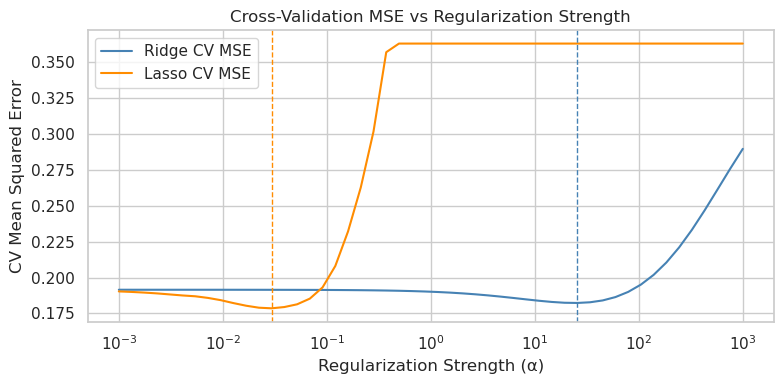

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
alphas = np.logspace(-3, 3, 50)

ridge_cv_scores, lasso_cv_scores = [], []

for alpha in alphas:
    r_scores = cross_val_score(Ridge(alpha=alpha), X_train_sc, y_train_reg,
                               cv=kf, scoring='neg_mean_squared_error')
    l_scores = cross_val_score(Lasso(alpha=alpha, max_iter=10000), X_train_sc, y_train_reg,
                               cv=kf, scoring='neg_mean_squared_error')
    ridge_cv_scores.append(-r_scores.mean())
    lasso_cv_scores.append(-l_scores.mean())

best_alpha_ridge = alphas[np.argmin(ridge_cv_scores)]
best_alpha_lasso = alphas[np.argmin(lasso_cv_scores)]
print(f'Best Ridge α: {best_alpha_ridge:.4f}')
print(f'Best Lasso α: {best_alpha_lasso:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, ridge_cv_scores, label='Ridge CV MSE', color='steelblue')
ax.plot(alphas, lasso_cv_scores, label='Lasso CV MSE', color='darkorange')
ax.axvline(best_alpha_ridge, color='steelblue', linestyle='--', linewidth=1)
ax.axvline(best_alpha_lasso, color='darkorange', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Regularization Strength (α)')
ax.set_ylabel('CV Mean Squared Error')
ax.set_title('Cross-Validation MSE vs Regularization Strength')
ax.legend()
plt.tight_layout()
plt.show()

This plot shows how the cross validation mean squared error changes as the regularization strength varies for Ridge and Lasso regression models. The x-axis uses a log scale to display a wide range of α values. Ridge remains stable across a wide range of α values, only rising sharply above α=10. Lasso is much more sensitive as it finds its best performance at a very small α (0.03) and deteriorates quickly with more regularization. This suggests Lasso needs less regularization to perform well on this data The lowest point on each curve represents the best-performing α. The dashed vertical lines highlight these optimalvalues for Ridge and Lasso. Overall the plot illustrates the trade-off between model complexity and regularization, helping identify the α that minimizes prediction error for each model. 

In [ ]:
# Fit best models on full training set
ridge = Ridge(alpha=best_alpha_ridge).fit(X_train_sc, y_train_reg)
lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000).fit(X_train_sc, y_train_reg)

# Evaluate on test set
for name, model in [('Ridge', ridge), ('Lasso', lasso)]:
    preds = model.predict(X_test_sc)
    print(f'{name} - Test RMSE: {np.sqrt(mean_squared_error(y_test_reg, preds)):.3f}, '
          f'R²: {r2_score(y_test_reg, preds):.3f}')

Ridge - Test RMSE: 0.309, R²: 0.504
Lasso - Test RMSE: 0.295, R²: 0.548


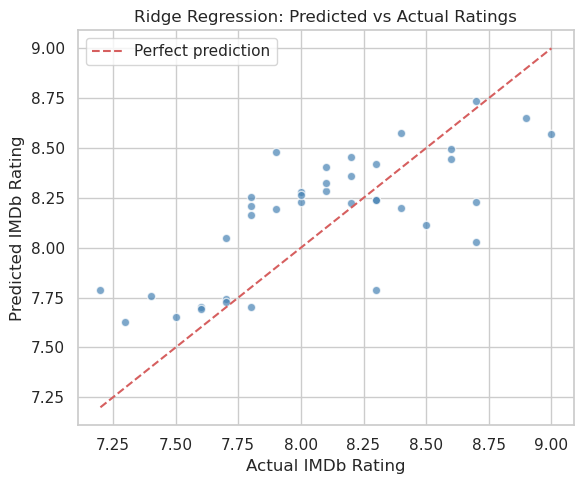

In [ ]:
# Predicted vs Actual - Ridge
ridge_preds = ridge.predict(X_test_sc)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test_reg, ridge_preds, alpha=0.7, color='steelblue', edgecolors='white')
ax.plot([y_test_reg.min(), y_test_reg.max()],
        [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual IMDb Rating')
ax.set_ylabel('Predicted IMDb Rating')
ax.set_title('Ridge Regression: Predicted vs Actual Ratings')
ax.legend()
plt.tight_layout()
plt.show()

This scatter plot compares actual IMDb ratings with those predicted by the Ridge regression model. Each point can be read as an episode with the true  rating on the x-axis and predicted rating on the y-axis. The dashed diagonal line indicates perfect predictions, where predicted values exactly match the actual values, ie. points close to this line show accurate predictions while those farther away indicate errors. The cluster of points around the line indicates reasonable performance with small limitations in prediction accuracy.

### 5.3 Lasso Coefficients - Feature Importance

Lasso's sparsity property allows us to interpret which features it considers most important - those with non-zero coefficients.

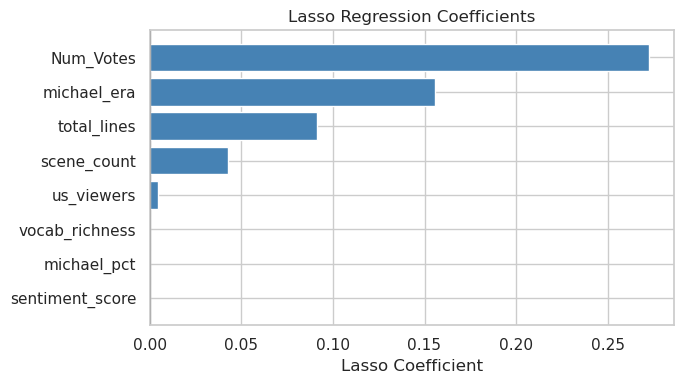

In [ ]:
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lasso.coef_})
coef_df = coef_df.sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lasso Coefficient')
ax.set_title('Lasso Regression Coefficients')
plt.tight_layout()
plt.show()

Features with positive coefficients increase predicted rating; negative ones decrease it. `Num_Votes` and `michael_era` are the strongest predictors. Notably, michael_pct, sentiment_score, and vocab_richness were all zeroed out by Lasso, meaning the model found them uninformative once other features were included. This horizontal bar chart shows the coefficients from the Lasso regression model for each feature. Features are sorted by their coefficient values. Larger bars indicate stronger influence, while coefficients close to zero suggest little to no impact. Overall, the plot highlights which features are most influential in predicting episode ratings and in what direction.  

---
### 5.4 Classification - Logistic Regression

We train a regularized Logistic Regression to classify whether an episode is a hit (IMDb ≥ 8.5). We again use cross-validation to select the regularization parameter C (inverse of α).

In [ ]:
C_values = np.logspace(-3, 3, 30)
clf_cv_scores = []

for C in C_values:
    scores = cross_val_score(
        LogisticRegression(C=C, max_iter=1000, random_state=SEED),
        X_train_sc, y_train_clf, cv=kf, scoring='accuracy'
    )
    clf_cv_scores.append(scores.mean())

best_C = C_values[np.argmax(clf_cv_scores)]
print(f'Best C: {best_C:.4f}')

# Fit final classifier
clf = LogisticRegression(C=best_C, max_iter=1000, random_state=SEED)
clf.fit(X_train_sc, y_train_clf)

y_pred_clf = clf.predict(X_test_sc)
print()
print(classification_report(y_test_clf, y_pred_clf, target_names=['Not a Hit', 'Hit']))

Best C: 2.0434

              precision    recall  f1-score   support

   Not a Hit       0.90      0.93      0.92        30
         Hit       0.71      0.62      0.67         8

    accuracy                           0.87        38
   macro avg       0.81      0.78      0.79        38
weighted avg       0.86      0.87      0.87        38



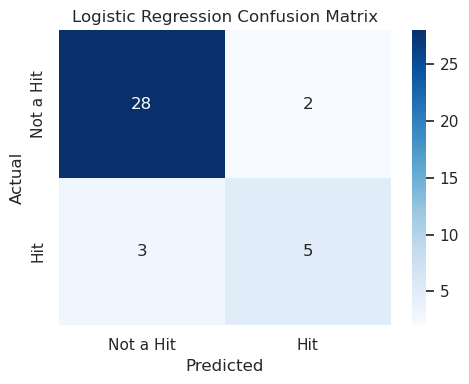

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not a Hit', 'Hit'],
            yticklabels=['Not a Hit', 'Hit'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

This heatmap shows the confusion matrix for a logistic regression model classifying episodes as "Hit" or "Not a Hit". The x-axis represents predicted labels, and the y-axis shows actual labels. Each cell indicates the number of episodes in that category. The model correctly classified 28 non-hit and 5 hit episodes, giving an overall accuracy of 87.5%. It missed 3 hit episodes (false negatives), which is understandable given the class imbalance in the dataset. 

---
### 5.5 Clustering - Episode Dialogue Profiles

We apply K-Means clustering on the dialogue features to discover natural groupings of episodes. We use the elbow method to choose k, then visualize clusters in 2D using PCA.

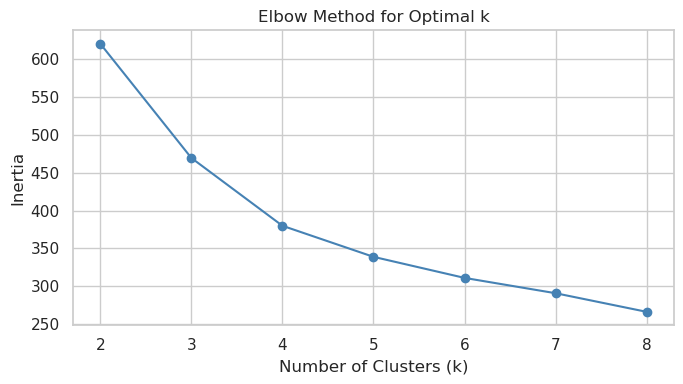

In [ ]:
# Use only dialogue features for clustering (no target leakage)
CLUSTER_FEATURES = ['total_lines', 'scene_count', 'michael_pct',
                    'sentiment_score', 'vocab_richness']
X_clust = StandardScaler().fit_transform(df[CLUSTER_FEATURES])

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, 'o-', color='steelblue')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()

This line plot illustrates how the episodes can be grouped based on dialogue features. As number of clusters increases episodes can be divided into more refined groupings, improving how well similar episodes are categorized. The curve shows the clearest bend at k=3, after which the improvement in inertia becomes marginal. We therefore chose k=3 for our clustering. This helps determine an optimal number of episode types, which can then be compared against ratings and viewership to assess certain character-driven episode styles. 

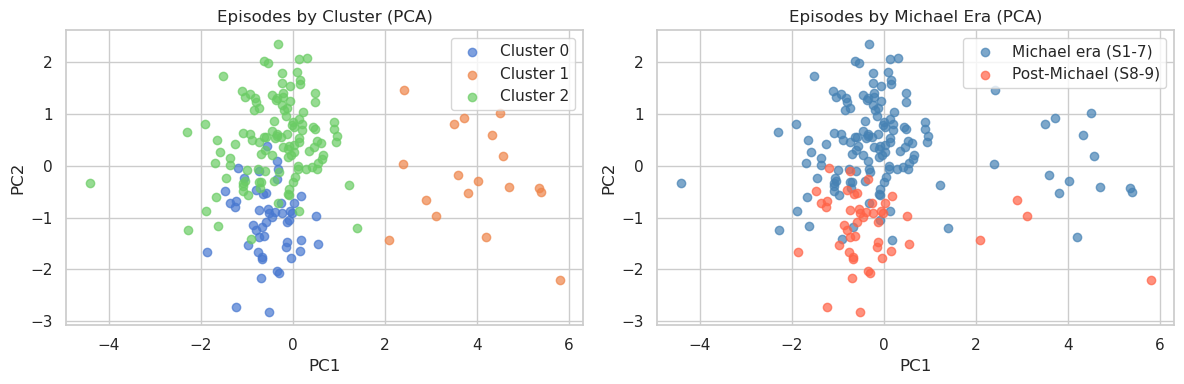

In [ ]:
# Fit K=3 clusters
km = KMeans(n_clusters=3, random_state=SEED, n_init=10)
df['cluster'] = km.fit_predict(X_clust)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clust)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Coloured by cluster
for cluster_id in range(3):
    mask = df['cluster'] == cluster_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {cluster_id}', alpha=0.7)
axes[0].set_title('Episodes by Cluster (PCA)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Coloured by Michael era
for era, label, color in [(1, 'Michael era (S1-7)', 'steelblue'), (0, 'Post-Michael (S8-9)', 'tomato')]:
    mask = df['michael_era'] == era
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=label, color=color, alpha=0.7)
axes[1].set_title('Episodes by Michael Era (PCA)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

plt.tight_layout()
plt.show()

Cluster 1 stands out as the high-engagement group as it has the most lines (502), most scenes (75), and the highest average rating of 8.93. These are longer, more dialogue-heavy episodes that tend to rate well. Cluster 2 has moderate Michael presence (28%) and a rating of 8.35, while Cluster 0 has almost no Michael dialogue (1%) and the lowest average rating of 7.73. The second plot confirms that post-Michael episodes (Seasons 8-9) fall almost entirely in Cluster 0, while Michael-era episodes are spread across Clusters 1 and 2. This suggests episode structure changed significantly after his departure.

In [ ]:
# Cluster profile summary
df.groupby('cluster')[CLUSTER_FEATURES + ['Rating']].mean().round(3)

,total_lines,scene_count,michael_pct,sentiment_score,vocab_richness,Rating
cluster,,,,,,
0,275.740,40.480,0.010,0.129,0.378,7.730
1,502.222,74.833,0.183,0.142,0.314,8.933
2,269.432,40.551,0.284,0.130,0.369,8.352


This project analyzed the television series The Office (US), which aired from 2005 to 2013 and is widely considered one of the most influential sitcoms of its time, and its major shift from Season 7 when the central character, Michael Scott, left the show. This departure is often associated with a perceived decline in quality, making it a key point of investigation.

Through the study, we were able to determine whether episode quality measured through IMDb ratings can be predicted using dialogue patterns and episode-level characteristics. The project integrated multiple data sources, including episode metadata (viewership, writers, and directors), IMDb ratings, and full dialogue transcripts. From these, meaningful features were engineered, particularly those capturing character prominence and conversational dynamics.

Three main analytical approaches were used. First, a regression model to predict the exact IMDb rating of an episode based on its features, helping quantify how dialogue and structure relate to audience reception. Second, a classification model identified whether an episode is a "hit" (defined as an IMDb rating of 8.5 or higher), offering a clearer distinction between high- and average-performing episodes. Finally, clustering techniques grouped episodes based on dialogue patterns to uncover natural categories, which were then compared to the pre- and post-Michael eras.

The data supports the view that Michael Scott's departure hurt the show. Post-Michael episodes cluster almost entirely in the lowest-rated group (avg rating 7.73), while Michael-era episodes dominate the higher-rated clusters (avg ratings 8.93 and 8.35). The regression model confirmed Num_Votes and michael_era as the strongest predictors of episode quality, while the classifier correctly identified 87.5% of episodes as hits or non-hits. Together, the models show that the show's perceived decline after Season 7 is not just fan opinion but it is measurable in the dialogue data itself.